# Semi-Supervised Missing Label Learning - Interactive Demo

Welcome to the interactive demonstration of our missing label learning project. This notebook is designed for new users to evaluate our custom logistic regression models (`novel`, `saute-half`, `labeled_only`, and `oracle`) on **any custom dataset**.

### What this notebook does:
1. **Data Loading**: Accepts any dataset as `X` (features) and `y` (binary labels).
2. **Missing Label Generation**: Artificially masks labels according to different mechanisms (MCAR, MAR1, MAR2, MNAR).
3. **PCA Visualization**: Shows how the missing labels and model predictions look in a 2D projected feature space.
4. **Performance Evaluation**: Runs parallelized experiments across varying missing rates and plots the selected metric of interest.

In [1]:
import os
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import project-specific modules
from src.data_prep import generate_missing_labels
from src.evaluation import compute_binary_metrics
from src.fista import FistaLogisticRegression
from src.novel_logreg import novel_logreg
from src.pl_logreg import logreg_with_saute

warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

## 1. Load Your Dataset
Below, we load the `breast_cancer` dataset as an example.

**Instructions for your own data:**
Simply replace `X` and `y` with your own `np.ndarray` objects.
* `X` should be a 2D float array of features `(n_samples, n_features)`.
* `y` should be a 1D integer array of binary labels `{0, 1}` of length `n_samples`.

In [2]:
# ---------------------------------------------------------
# REPLACE THIS BLOCK WITH YOUR OWN DATA LOADING LOGIC
# ---------------------------------------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Ensure arrays are correctly typed
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=int)

print(f"Dataset loaded successfully!")
print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape:   {y.shape}")
print(f"Class distribution: 0: {np.sum(y==0)}, 1: {np.sum(y==1)}")

Dataset loaded successfully!
Features (X) shape: (569, 30)
Labels (y) shape:   (569,)
Class distribution: 0: 212, 1: 357


## 2. PCA Visualization: Missing Labels vs. Predictions
Let's see how our data looks when projected onto 2D using PCA. We will generate missing labels (using a 50% missing rate) for four different mechanisms: `MCAR`, `MAR1`, `MAR2`, and `MNAR`.

First, we will visualize the **Novel** method, followed by the **Saute-Half** method.

[generate_missing_labels] scheme=MCAR   target=0.50  actual=0.503
[generate_missing_labels] scheme=MAR1   target=0.50  actual=0.525
[generate_missing_labels] scheme=MAR2   target=0.50  actual=0.487
[generate_missing_labels] scheme=MNAR   target=0.50  actual=0.508


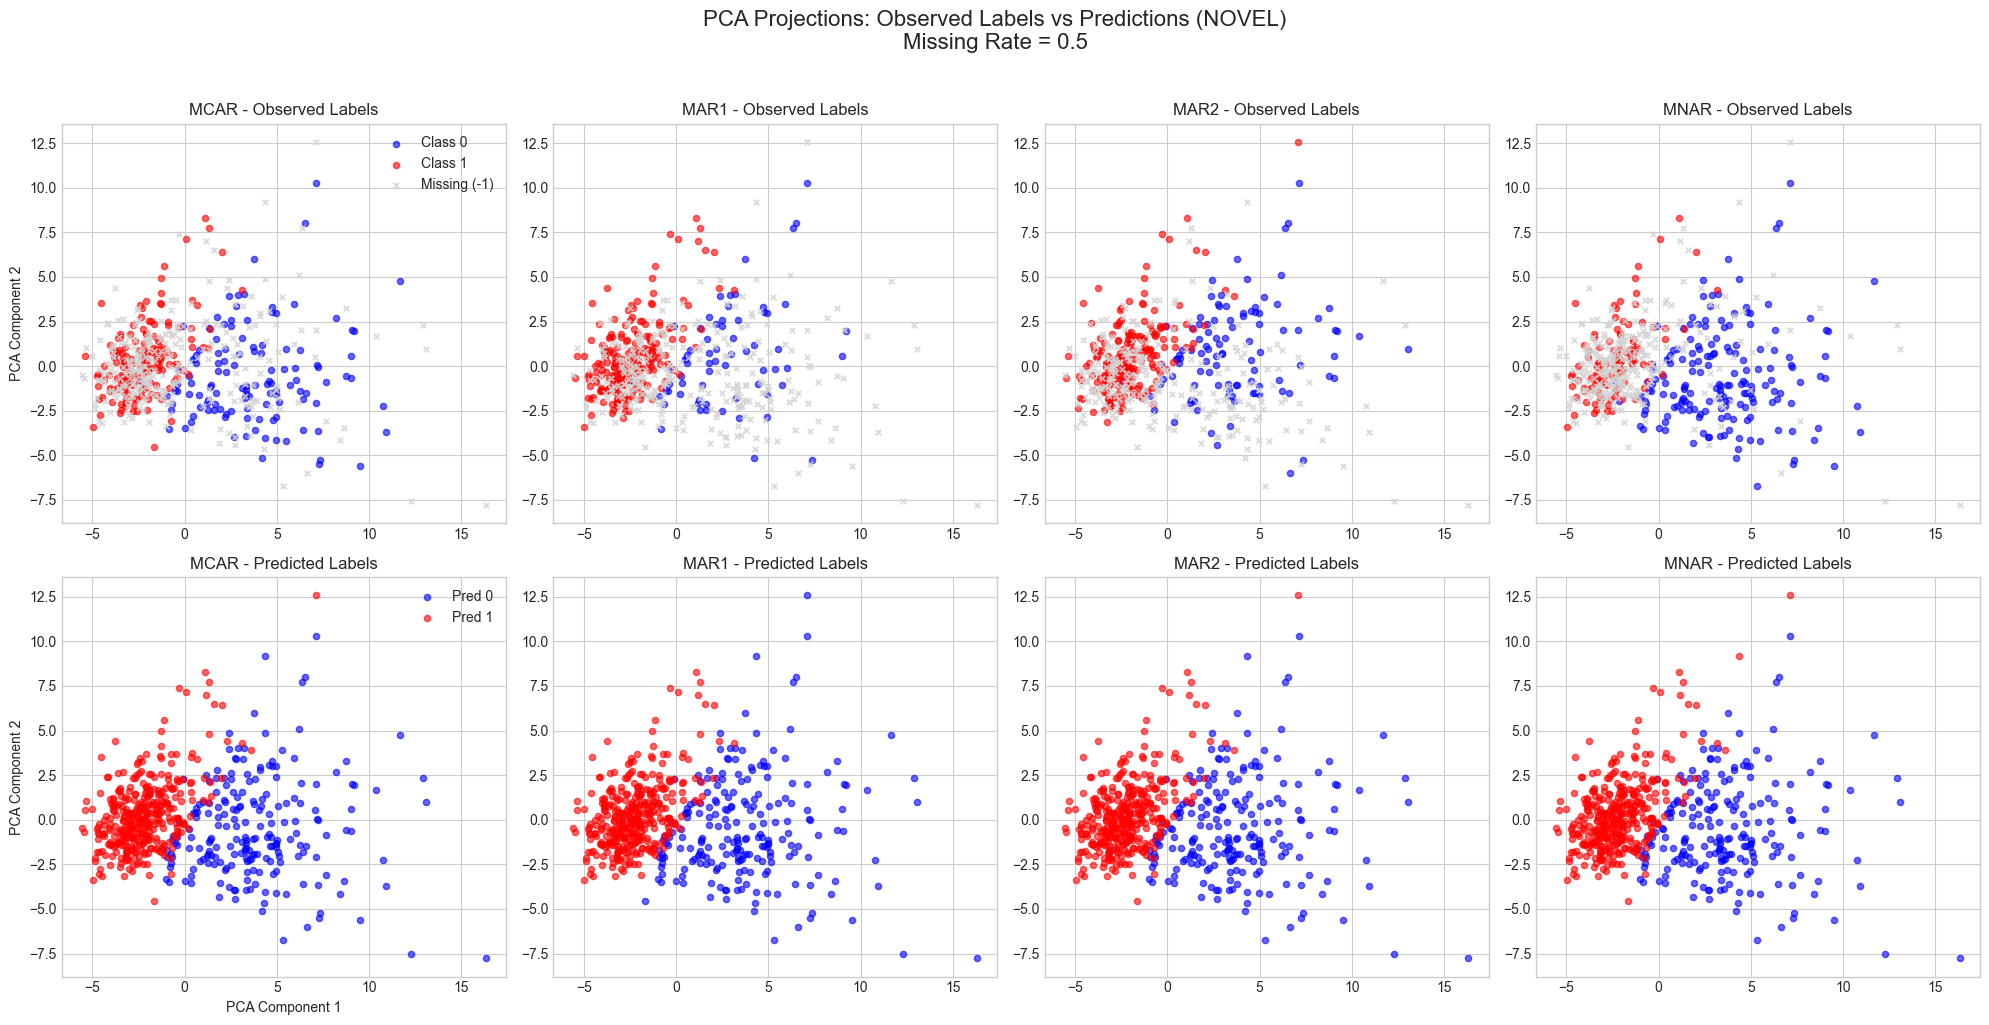

[generate_missing_labels] scheme=MCAR   target=0.50  actual=0.503
[generate_missing_labels] scheme=MAR1   target=0.50  actual=0.525
[generate_missing_labels] scheme=MAR2   target=0.50  actual=0.487
[generate_missing_labels] scheme=MNAR   target=0.50  actual=0.508


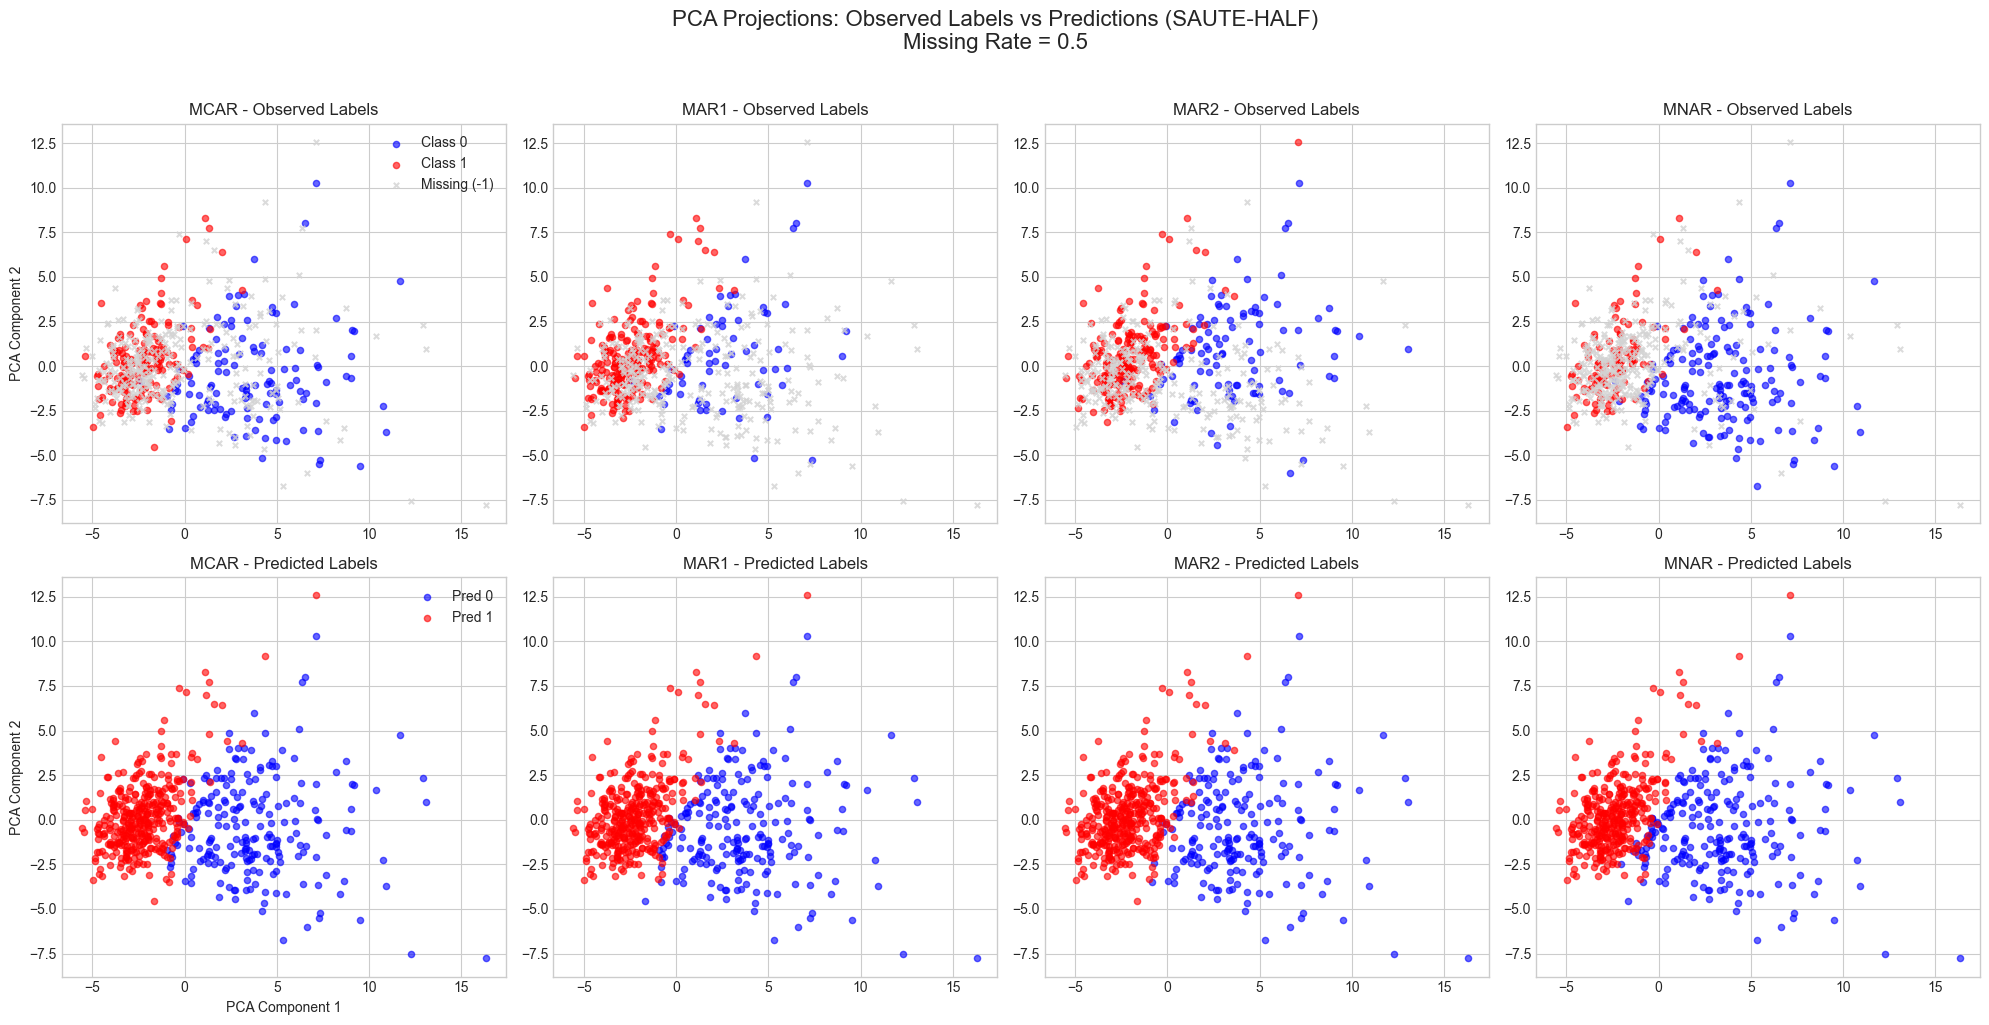

In [3]:
MISSING_RATE_VIZ = 0.5
SCHEMES = ["MCAR", "MAR1", "MAR2", "MNAR"]

# Scale data and project to 2D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

def plot_pca_for_method(method_name):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f"PCA Projections: Observed Labels vs Predictions ({method_name.upper()})\nMissing Rate = {MISSING_RATE_VIZ}", fontsize=16, y=1.02)

    for i, scheme in enumerate(SCHEMES):
        # Generate missing labels
        y_obs = generate_missing_labels(X_scaled, y, scheme=scheme, missing_rate=MISSING_RATE_VIZ, random_state=42)

        # Train the selected method (for visualization purposes, trained on the whole set)
        if method_name == 'novel':
            model = novel_logreg(X_scaled, y_obs, X_scaled, y, n_iter=10)
        elif method_name == 'saute-half':
            n_vars_half = max(1, X_scaled.shape[1] // 2)
            model = logreg_with_saute(X_scaled, y_obs, n_vars=n_vars_half, use_selection=False)
            model.validate(X_scaled, y, measure="balanced_accuracy")

        y_pred = model.predict(X_scaled)

        # Plot ROW 1: Observed Labels
        ax_obs = axes[0, i]
        ax_obs.set_title(f"{scheme} - Observed Labels")

        mask_missing = (y_obs == -1)
        mask_0 = (y_obs == 0)
        mask_1 = (y_obs == 1)

        ax_obs.scatter(X_pca[mask_0, 0], X_pca[mask_0, 1], color='blue', alpha=0.6, label='Class 0', s=20)
        ax_obs.scatter(X_pca[mask_1, 0], X_pca[mask_1, 1], color='red', alpha=0.6, label='Class 1', s=20)
        ax_obs.scatter(X_pca[mask_missing, 0], X_pca[mask_missing, 1], color='lightgray', alpha=0.8, label='Missing (-1)', s=15, marker='x')

        if i == 0:
            ax_obs.legend()
            ax_obs.set_ylabel("PCA Component 2")

        # Plot ROW 2: Predicted Labels
        ax_pred = axes[1, i]
        ax_pred.set_title(f"{scheme} - Predicted Labels")

        pred_0 = (y_pred == 0)
        pred_1 = (y_pred == 1)

        ax_pred.scatter(X_pca[pred_0, 0], X_pca[pred_0, 1], color='blue', alpha=0.6, label='Pred 0', s=20)
        ax_pred.scatter(X_pca[pred_1, 0], X_pca[pred_1, 1], color='red', alpha=0.6, label='Pred 1', s=20)

        if i == 0:
            ax_pred.legend()
            ax_pred.set_ylabel("PCA Component 2")
            ax_pred.set_xlabel("PCA Component 1")

    plt.tight_layout()
    plt.show()

# Generate both plots
plot_pca_for_method('novel')
plot_pca_for_method('saute-half')

## 3. Parallelized Performance Evaluation
Now, we will evaluate the models (`oracle`, `labeled_only`, `novel`, `saute-half`) across different missing rates (from 0.1 to 0.9). To save time, these experiments are executed in parallel.

You can change the `METRIC_OF_INTEREST` and the evaluation `SCHEME` below.

In [4]:
# --- EXPERIMENT CONFIGURATION ---
METRIC_OF_INTEREST = "balanced_accuracy"  # Try: 'roc_auc', 'f1', 'recall', 'precision', 'pr_auc'
EVALUATION_SCHEME = "MAR1"                # Scheme to test: 'MCAR', 'MAR1', 'MAR2', 'MNAR'

METHODS_TO_TEST = ["oracle", "labeled_only", "novel", "saute-half"]
MISSING_RATES = np.arange(0.1, 0.9, 0.1)
SEEDS = [42, 123, 2026]
N_JOBS = -1

In [5]:
def run_single_experiment(X, y, missing_rate, seed, method, scheme):
    """Worker function to run a single setup inside the parallel pool."""
    # Split data: Train (60%), Val (20%), Test (20%)
    X_train, X_test, y_train_true, y_test_true = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    X_fit, X_val, y_fit_true, y_val_true = train_test_split(
        X_train, y_train_true, test_size=0.25, random_state=seed, stratify=y_train_true
    )

    # Scale features
    scaler = StandardScaler()
    X_fit = scaler.fit_transform(X_fit)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Generate missing labels for the fit set ONLY
    y_fit_obs = generate_missing_labels(
        X_fit, y_fit_true, scheme=scheme, missing_rate=missing_rate, random_state=seed
    )

    # Initialize metric defaults
    result = {
        "missing_rate": missing_rate,
        "method": method,
        "seed": seed,
        "score": np.nan
    }

    try:
        if method == "oracle":
            model = FistaLogisticRegression()
            model.fit(X_fit, y_fit_true) # Oracle sees TRUE labels
            model.validate(X_val, y_val_true, measure=METRIC_OF_INTEREST)

        elif method == "labeled_only":
            mask = (y_fit_obs != -1)
            model = FistaLogisticRegression()
            if len(np.unique(y_fit_obs[mask])) > 1: # check if both classes exist
                model.fit(X_fit[mask], y_fit_obs[mask])
                model.validate(X_val, y_val_true, measure=METRIC_OF_INTEREST)
            else:
                return result # Return NaN if all remaining labels are of one class

        elif method == "novel":
            model = novel_logreg(X_fit, y_fit_obs, X_val, y_val_true, n_iter=15)

        elif method == "saute-half":
            n_vars = max(1, X_fit.shape[1] // 2)
            model = logreg_with_saute(X_fit, y_fit_obs, n_vars=n_vars, use_selection=False)
            model.validate(X_val, y_val_true, measure=METRIC_OF_INTEREST)

        # Predict and evaluate
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        metrics = compute_binary_metrics(y_test_true, y_pred, y_proba)

        result["score"] = metrics.get(METRIC_OF_INTEREST, np.nan)

    except Exception as e:
        print(f"Failed {method} at rate {missing_rate}: {e}")

    return result

# Prepare task arguments
tasks = []
for rate in MISSING_RATES:
    for seed in SEEDS:
        for method in METHODS_TO_TEST:
            tasks.append((X, y, rate, seed, method, EVALUATION_SCHEME))

print(f"Starting {len(tasks)} parallel experiments (Metric: {METRIC_OF_INTEREST}, Scheme: {EVALUATION_SCHEME})...")

# Run parallel execution (joblib is very stable in Jupyter notebooks)
results = Parallel(n_jobs=N_JOBS)(
    delayed(run_single_experiment)(*task) for task in tasks
)

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("Experiments finished!")

Starting 96 parallel experiments (Metric: balanced_accuracy, Scheme: MAR1)...
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.147
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.147
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.147
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.147
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.161
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.123
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.123
[generate_missing_labels] scheme=MAR1   target=0.20  actual=0.246
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.161
[generate_missing_labels] scheme=MAR1   target=0.20  actual=0.246
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.123
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.123
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.161
[generate_missing_labels] scheme=MAR1   target=0.10  actual=0.16

## 4. Plotting the Results
Finally, let's plot the performance of our models as the missing label rate increases. We will plot the mean value with standard deviation error bars.

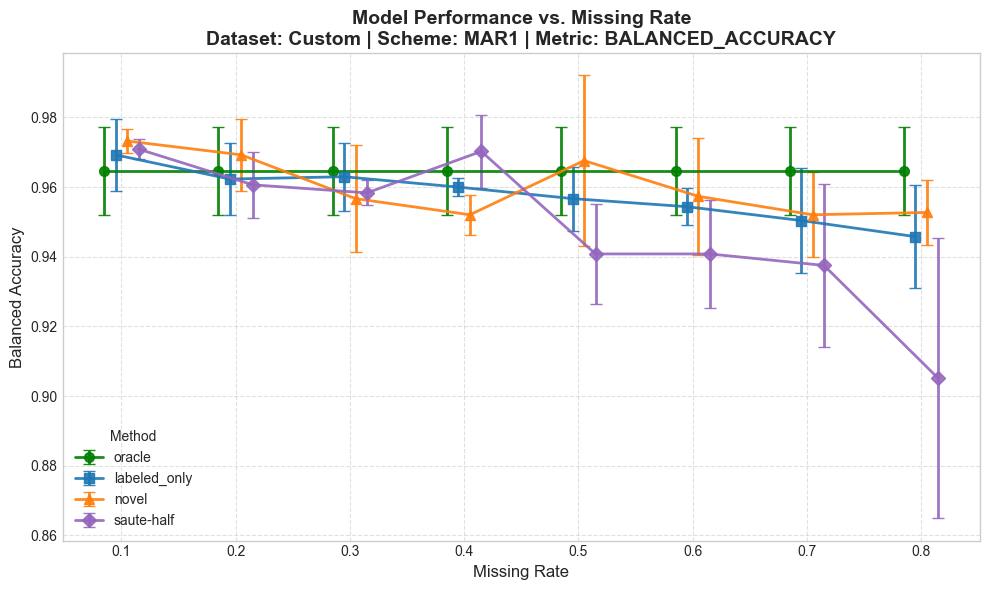

In [6]:
# Aggregate results
df_agg = df_results.groupby(["missing_rate", "method"], dropna=False)["score"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(10, 6))

markers = {"oracle": "o", "labeled_only": "s", "novel": "^", "saute-half": "D"}
colors = {"oracle": "green", "labeled_only": "tab:blue", "novel": "tab:orange", "saute-half": "tab:purple"}

for i, method in enumerate(METHODS_TO_TEST):
    group = df_agg[df_agg["method"] == method].sort_values("missing_rate")

    x = group["missing_rate"].to_numpy()
    y_mean = group["mean"].to_numpy()
    y_std = group["std"].fillna(0.0).to_numpy()

    # Slight jitter to avoid overlapping error bars
    offset = (i - (len(METHODS_TO_TEST) - 1) / 2) * 0.01
    x_jitter = x + offset

    plt.errorbar(
        x_jitter, y_mean, yerr=y_std,
        label=method, marker=markers.get(method, "o"),
        color=colors.get(method, "black"),
        capsize=4, linewidth=2, markersize=7, alpha=0.9
    )

plt.title(f"Model Performance vs. Missing Rate\nDataset: Custom | Scheme: {EVALUATION_SCHEME} | Metric: {METRIC_OF_INTEREST.upper()}", fontsize=14, fontweight='bold')
plt.xlabel("Missing Rate", fontsize=12)
plt.ylabel(METRIC_OF_INTEREST.replace("_", " ").title(), fontsize=12)

# Set grid and legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(MISSING_RATES)
plt.legend(title="Method", framealpha=0.9, loc='lower left')

plt.tight_layout()
plt.show()